# Real-time score following experiments

The following Jupyter notebook contains experiments, which evaluate different models against real-time score following problem. These models are:

- OTW
- CYOLO-SB+A

Evaluation is performed with the use of selected pieces from MAESTRO dataset, while for specific synthetic experiments it uses custom pieces emphasizing potential pain points in these models.

## 0. Preparation

First let's define modules to import, hyperparameters of the experiments, locate MAESTRO dataset and prepare the models that are evaluated.

In [1]:
import os.path
from typing import Dict

from evaluation.evaluator import Evaluator
from evaluation.metrics import MetricKeys, EvaluationMetrics
from experiments.experiments_runner import ExperimentsRunner
from models.cyolo_model import CYOLOModel
from models.otw_model import OTWModel
from experiments.maestro_reader import get_maestro_test_pairs
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [11]:
MAESTRO_PATH = r"C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0"
N_PIECES = 25
MAX_DURATION = 500
FIGURES_OUTPUT = "./figures"

os.makedirs(FIGURES_OUTPUT, exist_ok=True)

otw = OTWModel()
cyolo = CYOLOModel()
models = [otw, cyolo]

evaluator = Evaluator()
experiments_runner = ExperimentsRunner(evaluator, models)

Conditioning: ContextConditioning | Parameters: {'n_lstm_layers': 1, 'activation': 'nn.ELU', 'zdim': 128, 'normalize_input': True}
Using input normalization!
Evaluator initialized (tolerance: 0.5s)


In [3]:
pieces = get_maestro_test_pairs(MAESTRO_PATH, max_pieces=N_PIECES, max_duration=MAX_DURATION)

## 1. Single-dimensional evaluation

This section contains experiments, which perform the simplest evaluation. Each model is tested against a single metric from the selected:

- **mean accuracy** - factor of accurate estimations of current position in each audio frame (tolerance: 500ms)
- **mean latency** - average time needed to process a single audio frame
- **mean error** - average discrepancy between estimated and real position for each audio frame
- **tempo robustness** - factor of accurately estimated tempo values in each audio frame (tolerance: 10% reference BPM).

First, let's run the evaluation to collect all the base metrics.

In [4]:
def extract_single_metric_results(metrics: Dict[str, EvaluationMetrics], metric_key: MetricKeys) -> Dict[str, float]:
    results_for_metric: Dict[str, float] = {}

    for model_name in metrics:
        results_for_metric[model_name] = metrics[model_name].to_dict()[metric_key]

    return results_for_metric

In [5]:
results = experiments_runner.test_average_metrics(pieces, verbose=True)

Evaluating piece no. 1... (Path to MIDI: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi, path to audio: C:\Users\bkisl\Desktop\maestro-v3.0.0\maestro-v3.0.0\2004\MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.wav, ):   0%|          | 0/25 [00:00<?, ?it/s]E:\source\studies\PDYM\score-following-eval\.env\Lib\site-packages\torch\functional.py:681: UserWarning: stft with return_complex=False is deprecated. In a future pytorch release, stft will return complex tensors for all inputs, and return_complex=False will raise an error.
Note: you can still call torch.view_as_real on the complex output to recover the old return format. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\SpectralOps.cpp:879.)
  return _VF.stft(  # type: ignore[attr-defined]
E:\source\studies\PDYM\score-following-eval\.env\Lib\site-packages\torch\fun

### 1.1. Mean accuracy

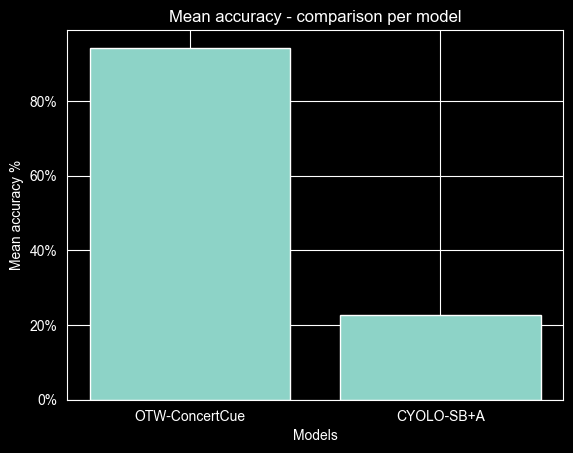

In [10]:
accuracy_results = extract_single_metric_results(results, MetricKeys.ACCURACY)

labels = list(accuracy_results.keys())
values = list(accuracy_results.values())

plt.figure()
plt.bar(labels, values)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xlabel("Models")
plt.ylabel("Mean accuracy %")
plt.title("Mean accuracy - comparison per model")

plt.savefig(os.path.join(FIGURES_OUTPUT, "1.1_accuracy.png"))
plt.show()

### 1.2. Mean latency

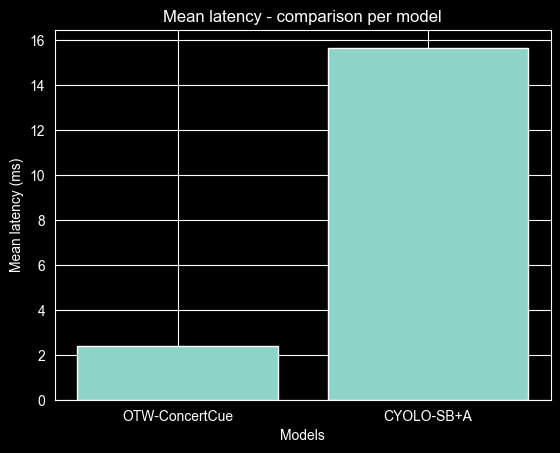

In [12]:
latency_results = extract_single_metric_results(results, MetricKeys.MEAN_LATENCY)

labels = list(latency_results.keys())
values = list(latency_results.values())

plt.figure()
plt.bar(labels, values)

plt.xlabel("Models")
plt.ylabel("Mean latency (ms)")
plt.title("Mean latency - comparison per model")

plt.savefig(os.path.join(FIGURES_OUTPUT, "1.2_latency.png"))
plt.show()

### 1.3. Mean error

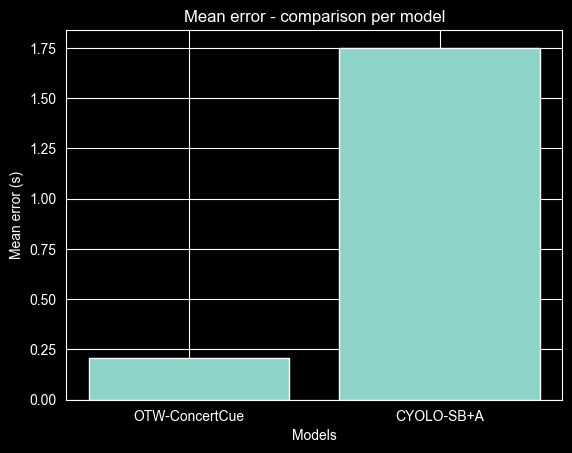

In [13]:
error_results = extract_single_metric_results(results, MetricKeys.MEAN_ERROR)

labels = list(error_results.keys())
values = list(error_results.values())

plt.figure()
plt.bar(labels, values)

plt.xlabel("Models")
plt.ylabel("Mean error (s)")
plt.title("Mean error - comparison per model")

plt.savefig(os.path.join(FIGURES_OUTPUT, "1.3_error.png"))
plt.show()